### A/B Testing & Statistical Analysis

#### Business Problem

The game team observed that a significant number of players do not continue playing after their initial sessions. To improve player retention, two interventions were tested against the existing game experience:
- **Control:** Existing game experience
- **Free Hint:** Players receive an additional free hint
- **Daily Reward:** Players receive a daily reward for returning to the game

#### Experiment Objective

The primary objective is to determine whether either intervention significantly improves **D7 retention** compared with the Control group.

Secondary objectives include evaluating the impact on:

- Purchase conversion
- Revenue per player

The final decision will consider both **statistical significance** and **business impact**.

In [2]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind , mannwhitneyu

from statsmodels.stats.multitest import multipletests

import warnings 
warnings.filterwarnings("ignore")

In [3]:
# load the dataset
players = pd.read_csv(r"D:\A-B testing\Data\raw\players.csv")
game_activity = pd.read_csv(r"D:\A-B testing\Data\raw\game_activity.csv")
transactions = pd.read_csv(r"D:\A-B testing\Data\raw\transactions.csv")

print("Players:", players.shape)
print("Game Activity:", game_activity.shape)
print("Transactions:", transactions.shape)

Players: (30000, 7)
Game Activity: (120760, 9)
Transactions: (2711, 5)


In [4]:
# creating the Experiment analysis dataset

## d7 retention
d7_players = (
    game_activity.loc[
        game_activity["days_since_signup"] == 7,
        "player_id"
    ]
    .unique()
)

# base dataset
experiment_data = players[
    ["player_id", "experiment_group"]
].copy()

# add the d7 flag
experiment_data["d7_retained"] = (
    experiment_data["player_id"]
    .isin(d7_players)
    .astype(int)
)

# add purchase conversion
purchasing_players = transactions["player_id"].unique()

experiment_data["made_purchase"] = (
    experiment_data["player_id"]
    .isin(purchasing_players)
    .astype(int)
)

In [5]:
# revenue per player

# calculate total_revenue
player_revenue = (
    transactions
    .groupby("player_id")["amount"]
    .sum()
    .reset_index(name="total_revenue")
)

experiment_data = experiment_data.merge(
    player_revenue,
    on="player_id",
    how="left"
)

experiment_data["total_revenue"] = (
    experiment_data["total_revenue"]
    .fillna(0)
)

In [6]:
# validate group size
experiment_data.head()

,player_id,experiment_group,d7_retained,made_purchase,total_revenue
0,P00001,Daily_Reward,1,0,0.00
1,P00002,Control,1,0,0.00
2,P00003,Control,0,0,0.00
3,P00004,Daily_Reward,0,1,3.14
4,P00005,Control,0,0,0.00


In [7]:
experiment_data["experiment_group"].value_counts()

experiment_group
Daily_Reward    10000
Control         10000
Free_Hint       10000
Name: count, dtype: int64

In [8]:
# grouping metrics based on experiment_group
experiment_data.groupby("experiment_group").agg(
    players=("player_id", "count"),
    d7_retention=("d7_retained", "mean"),
    purchase_conversion=("made_purchase", "mean"),
    avg_revenue=("total_revenue", "mean")
).round(4)

,players,d7_retention,purchase_conversion,avg_revenue
experiment_group,,,,
Control,10000,0.1464,0.0605,0.4739
Daily_Reward,10000,0.1832,0.0771,0.6291
Free_Hint,10000,0.1945,0.0563,0.3947


## Hypothesis Testing

### Primary KPI: D7 Retention

D7 retention is a binary metric, where:

- `1` = Player was active exactly on Day 7 after signup (Retained on Day 7)
- `0` = Player was not active on Day 7 (Not retained on Day 7)

For each comparison:

### Null Hypothesis (H₀)

There is no difference in D7 retention between the two experiment groups.

### Alternative Hypothesis (H₁)

There is a difference in D7 retention between the two experiment groups.

A two-sided test is used because both positive and negative effects are relevant.

### Significance Level

We use:

**α = 0.05**

If the p-value is less than 0.05, we reject the null hypothesis and conclude that the observed difference is statistically significant.

/we are basically going to compare between three groups based on D7 retention :
- **Control vs Free Hint**
- **Control vs Daily Reward** 
- **Free Hint vs Daily Reward**

In [9]:
# statistical testing function

""" 
this gives us
retention rate of Group 1
retention rate of Group 2
absolute difference in percentage points
Z-statistic
P-value
"""

def proportion_test(data, group1, group2, metric):
    
    group1_data = data[data["experiment_group"] == group1][metric]
    group2_data = data[data["experiment_group"] == group2][metric]
    
    successes = np.array([
        group1_data.sum(),
        group2_data.sum()
    ])
    
    sample_sizes = np.array([
        group1_data.count(),
        group2_data.count()
    ])
    
    z_stat, p_value = proportions_ztest(
        count=successes,
        nobs=sample_sizes,
        alternative="two-sided"
    )
    
    rate1 = group1_data.mean()
    rate2 = group2_data.mean()
    
    return {
        "Group 1": group1,
        "Group 2": group2,
        "Group 1 Rate (%)": round(rate1 * 100, 2),
        "Group 2 Rate (%)": round(rate2 * 100, 2),
        "Absolute Difference (pp)": round((rate2 - rate1) * 100, 2),
        "Z-statistic": round(z_stat, 4),
        "P-value": p_value
    }



In [10]:
## Control vs Free Hint

# Null Hypothesis (H₀) :D7 retention for Free Hint is equal to D7 retention for Control.
# Alternative Hypothesis (H₁) : D7 retention for Free Hint is different from D7 retention for Control.



control_vs_free_hint = proportion_test(
    data=experiment_data,
    group1="Control",
    group2="Free_Hint",
    metric="d7_retained"
)

control_vs_free_hint

{'Group 1': 'Control',
 'Group 2': 'Free_Hint',
 'Group 1 Rate (%)': np.float64(14.64),
 'Group 2 Rate (%)': np.float64(19.45),
 'Absolute Difference (pp)': np.float64(4.81),
 'Z-statistic': np.float64(-9.045),
 'P-value': np.float64(1.4961608511060522e-19)}

In [11]:
# the observed difference for retention on D7 is approximately: +4.81 percentage points

# check significance
if control_vs_free_hint["P-value"] < 0.05:
    print(
        "Result: Reject the null hypothesis. "
        "The difference is statistically significant."
    )
else:
    print(
        "Result: Fail to reject the null hypothesis. "
        "The difference is not statistically significant."
    )

Result: Reject the null hypothesis. The difference is statistically significant.


In [12]:
## Control vs Daily Reward

control_vs_daily_reward = proportion_test(
    data=experiment_data,
    group1="Control",
    group2="Daily_Reward",
    metric="d7_retained"
)

control_vs_daily_reward

{'Group 1': 'Control',
 'Group 2': 'Daily_Reward',
 'Group 1 Rate (%)': np.float64(14.64),
 'Group 2 Rate (%)': np.float64(18.32),
 'Absolute Difference (pp)': np.float64(3.68),
 'Z-statistic': np.float64(-7.0139),
 'P-value': np.float64(2.31781012591335e-12)}

In [13]:
# check significance

if control_vs_daily_reward["P-value"] < 0.05:
    print(
        "Result: Reject the null hypothesis. "
        "The difference is statistically significant."
    )
else:
    print(
        "Result: Fail to reject the null hypothesis. "
        "The difference is not statistically significant."
    )

Result: Reject the null hypothesis. The difference is statistically significant.


In [14]:
# Free Hint vs Daily Reward
free_hint_vs_daily_reward = proportion_test(
    data=experiment_data,
    group1="Free_Hint",
    group2="Daily_Reward",
    metric="d7_retained"
)

free_hint_vs_daily_reward

{'Group 1': 'Free_Hint',
 'Group 2': 'Daily_Reward',
 'Group 1 Rate (%)': np.float64(19.45),
 'Group 2 Rate (%)': np.float64(18.32),
 'Absolute Difference (pp)': np.float64(-1.13),
 'Z-statistic': np.float64(2.0415),
 'P-value': np.float64(0.0411988291833787)}

Difference : -1.13 percentage points when comparing **Daily Reward** against **Free Hint** in our function.

This is a much smaller difference, so it may or may not be statistically significant
    

In [15]:
# D7 test results

d7_test_results = pd.DataFrame([
    control_vs_free_hint,
    control_vs_daily_reward,
    free_hint_vs_daily_reward
])

d7_test_results

,Group 1,Group 2,Group 1 Rate (%),Group 2 Rate (%),Absolute Difference (pp),Z-statistic,P-value
0,Control,Free_Hint,14.64,19.45,4.81,-9.0450,1.496161e-19
1,Control,Daily_Reward,14.64,18.32,3.68,-7.0139,2.317810e-12
2,Free_Hint,Daily_Reward,19.45,18.32,-1.13,2.0415,4.119883e-02


In [16]:
d7_test_results["Significant (α=0.05)"] = (
    d7_test_results["P-value"] < 0.05
)

d7_test_results

,Group 1,Group 2,Group 1 Rate (%),Group 2 Rate (%),Absolute Difference (pp),Z-statistic,P-value,Significant (α=0.05)
0,Control,Free_Hint,14.64,19.45,4.81,-9.0450,1.496161e-19,True
1,Control,Daily_Reward,14.64,18.32,3.68,-7.0139,2.317810e-12,True
2,Free_Hint,Daily_Reward,19.45,18.32,-1.13,2.0415,4.119883e-02,True


In [17]:
alpha_adjusted = 0.05 / 3
d7_test_results["Significant After Bonferroni"] = (
    d7_test_results["P-value"] < alpha_adjusted
)

d7_test_results

#The more hypothesis tests we perform, the greater the chance of getting a false positive.
#So Bonferroni correction makes our decision more conservative.

,Group 1,Group 2,Group 1 Rate (%),Group 2 Rate (%),Absolute Difference (pp),Z-statistic,P-value,Significant (α=0.05),Significant After Bonferroni
0,Control,Free_Hint,14.64,19.45,4.81,-9.0450,1.496161e-19,True,True
1,Control,Daily_Reward,14.64,18.32,3.68,-7.0139,2.317810e-12,True,True
2,Free_Hint,Daily_Reward,19.45,18.32,-1.13,2.0415,4.119883e-02,True,False


##### /Findings
- Both Free Hint and Daily Reward produced statistically significant improvements in D7 retention compared with the Control group, even after applying the Bonferroni correction for multiple comparisons.
- Free Hint increased D7 retention by 4.81 percentage points, while Daily Reward increased it by 3.68 percentage points relative to Control.
- Although Free Hint showed a 1.13 percentage-point higher observed D7 retention than Daily Reward, this difference was not statistically significant after Bonferroni correction.

#### How large is the improvement, and what range of improvement is plausible?

In [18]:
# Create a 95% confidence Interval Function

def proportion_ci(data, group1, group2, metric, confidence=0.95):
    
    group1_data = data[data["experiment_group"] == group1][metric]
    group2_data = data[data["experiment_group"] == group2][metric]
    
    n1 = len(group1_data)
    n2 = len(group2_data)
    
    p1 = group1_data.mean()
    p2 = group2_data.mean()
    
    difference = p2 - p1
    
    se = np.sqrt(
        (p1 * (1 - p1) / n1) +
        (p2 * (1 - p2) / n2)
    )
    
    z_critical = 1.96
    
    lower_ci = difference - z_critical * se
    upper_ci = difference + z_critical * se
    
    return {
        "Group 1": group1,
        "Group 2": group2,
        "Difference (pp)": round(difference * 100, 2),
        "95% CI Lower (pp)": round(lower_ci * 100, 2),
        "95% CI Upper (pp)": round(upper_ci * 100, 2)
    }

In [19]:
# calculate confidence Intervals for all comparisons 
## Control vs Free Hint

ci_control_free_hint = proportion_ci(
    experiment_data,
    "Control",
    "Free_Hint",
    "d7_retained"
)

ci_control_free_hint

{'Group 1': 'Control',
 'Group 2': 'Free_Hint',
 'Difference (pp)': np.float64(4.81),
 '95% CI Lower (pp)': np.float64(3.77),
 '95% CI Upper (pp)': np.float64(5.85)}

In [20]:
## Control vs Daily Reward
ci_control_daily_reward = proportion_ci(
    experiment_data,
    "Control",
    "Daily_Reward",
    "d7_retained"
)

ci_control_daily_reward

{'Group 1': 'Control',
 'Group 2': 'Daily_Reward',
 'Difference (pp)': np.float64(3.68),
 '95% CI Lower (pp)': np.float64(2.65),
 '95% CI Upper (pp)': np.float64(4.71)}

In [21]:
## Free Hint vs Daily Reward
ci_free_hint_daily_reward = proportion_ci(
    experiment_data,
    "Free_Hint",
    "Daily_Reward",
    "d7_retained"
)

ci_free_hint_daily_reward

{'Group 1': 'Free_Hint',
 'Group 2': 'Daily_Reward',
 'Difference (pp)': np.float64(-1.13),
 '95% CI Lower (pp)': np.float64(-2.21),
 '95% CI Upper (pp)': np.float64(-0.05)}

In [22]:
## confidence intervals 
d7_confidence_intervals = pd.DataFrame([
    ci_control_free_hint,
    ci_control_daily_reward,
    ci_free_hint_daily_reward
])

d7_confidence_intervals

,Group 1,Group 2,Difference (pp),95% CI Lower (pp),95% CI Upper (pp)
0,Control,Free_Hint,4.81,3.77,5.85
1,Control,Daily_Reward,3.68,2.65,4.71
2,Free_Hint,Daily_Reward,-1.13,-2.21,-0.05


In [23]:
def relative_uplift(data, group1, group2, metric):
    
    p1 = (
        data[data["experiment_group"] == group1][metric]
        .mean()
    )
    
    p2 = (
        data[data["experiment_group"] == group2][metric]
        .mean()
    )
    
    uplift = ((p2 - p1) / p1) * 100
    
    return round(uplift, 2)

print(
    "Free Hint vs Control:",
    relative_uplift(
        experiment_data,
        "Control",
        "Free_Hint",
        "d7_retained"
    ),
    "%"
)

print(
    "Daily Reward vs Control:",
    relative_uplift(
        experiment_data,
        "Control",
        "Daily_Reward",
        "d7_retained"
    ),
    "%"
)

Free Hint vs Control: 32.86 %
Daily Reward vs Control: 25.14 %


#### Revenue per Player Statistical Analysis
Revenue per Player is different because:
- Many players have 0 revenue
- A small number of players may spend much more
- The distribution is likely right-skewed
- Revenue values are continuous

In [24]:
experiment_data.groupby("experiment_group")["total_revenue"].describe()

,count,mean,std,min,25%,50%,75%,max
experiment_group,,,,,,,,
Control,10000.0,0.473853,2.342340,0.0,0.0,0.0,0.0,54.96
Daily_Reward,10000.0,0.629134,2.681844,0.0,0.0,0.0,0.0,39.87
Free_Hint,10000.0,0.394670,1.981632,0.0,0.0,0.0,0.0,28.18


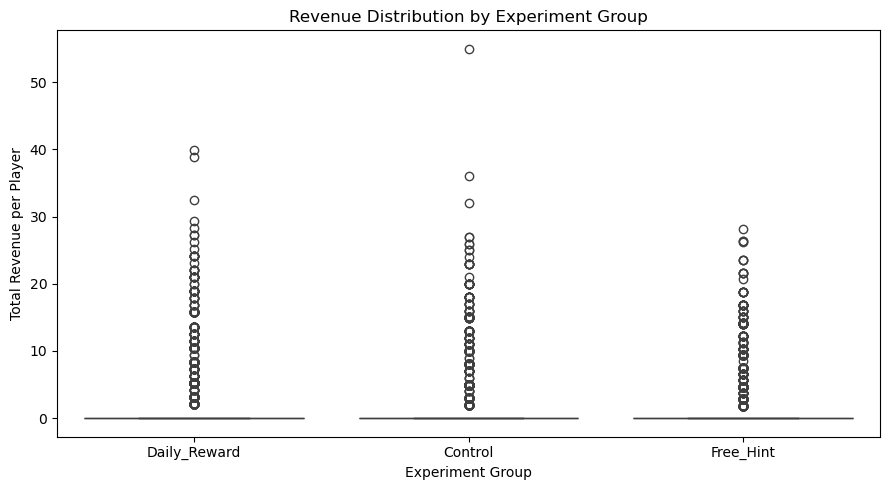

In [25]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=experiment_data,
    x="experiment_group",
    y="total_revenue"
)

plt.title("Revenue Distribution by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Total Revenue per Player")

plt.tight_layout()
plt.show()

In [27]:
# check mean and median revenue
revenue_stats = (
    experiment_data
    .groupby("experiment_group")["total_revenue"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Total_Revenue="sum"
    )
    .round(2)
)

revenue_stats

,Mean,Median,Std_Dev,Total_Revenue
experiment_group,,,,
Control,0.47,0.0,2.34,4738.53
Daily_Reward,0.63,0.0,2.68,6291.34
Free_Hint,0.39,0.0,1.98,3946.70


#### Statistical test for revenue

Mann–Whitney U test : It is a non-parametric test that does not require the data to be normally distributed.

Hypotheses : 
- H₀: The revenue distribution is the same between the two groups.
- H₁: The revenue distribution differs between the two groups.

In [29]:
# create a revenue test function
def revenue_test(data, group1, group2):
    
    revenue1 = data[
        data["experiment_group"] == group1
    ]["total_revenue"]
    
    revenue2 = data[
        data["experiment_group"] == group2
    ]["total_revenue"]
    
    statistic, p_value = mannwhitneyu(
        revenue1,
        revenue2,
        alternative="two-sided"
    )
    
    mean1 = revenue1.mean()
    mean2 = revenue2.mean()
    
    median1 = revenue1.median()
    median2 = revenue2.median()
    
    return {
        "Group 1": group1,
        "Group 2": group2,
        "Mean Revenue 1": round(mean1, 2),
        "Mean Revenue 2": round(mean2, 2),
        "Mean Difference": round(mean2 - mean1, 2),
        "Median Revenue 1": round(median1, 2),
        "Median Revenue 2": round(median2, 2),
        "P-value": p_value
    }

In [30]:
# testing the groups
## Control vs Daily Revenue
control_vs_daily_revenue = revenue_test(
    experiment_data,
    "Control",
    "Daily_Reward"
)

control_vs_daily_revenue


{'Group 1': 'Control',
 'Group 2': 'Daily_Reward',
 'Mean Revenue 1': np.float64(0.47),
 'Mean Revenue 2': np.float64(0.63),
 'Mean Difference': np.float64(0.16),
 'Median Revenue 1': 0.0,
 'Median Revenue 2': 0.0,
 'P-value': np.float64(1.5491081281829142e-06)}

In [31]:
## Control vs Free hint
control_vs_free_hint_revenue = revenue_test(
    experiment_data,
    "Control",
    "Free_Hint"
)

control_vs_free_hint_revenue

{'Group 1': 'Control',
 'Group 2': 'Free_Hint',
 'Mean Revenue 1': np.float64(0.47),
 'Mean Revenue 2': np.float64(0.39),
 'Mean Difference': np.float64(-0.08),
 'Median Revenue 1': 0.0,
 'Median Revenue 2': 0.0,
 'P-value': np.float64(0.15697070012410433)}

In [32]:
## Free hint vs Daily revenue
free_hint_vs_daily_revenue = revenue_test(
    experiment_data,
    "Free_Hint",
    "Daily_Reward"
)

free_hint_vs_daily_revenue

{'Group 1': 'Free_Hint',
 'Group 2': 'Daily_Reward',
 'Mean Revenue 1': np.float64(0.39),
 'Mean Revenue 2': np.float64(0.63),
 'Mean Difference': np.float64(0.23),
 'Median Revenue 1': 0.0,
 'Median Revenue 2': 0.0,
 'P-value': np.float64(1.1349636791507773e-09)}

In [33]:
# revenue test results

revenue_test_results = pd.DataFrame([
    control_vs_free_hint_revenue,
    control_vs_daily_revenue,
    free_hint_vs_daily_revenue
])

revenue_test_results

,Group 1,Group 2,Mean Revenue 1,Mean Revenue 2,Mean Difference,Median Revenue 1,Median Revenue 2,P-value
0,Control,Free_Hint,0.47,0.39,-0.08,0.0,0.0,1.569707e-01
1,Control,Daily_Reward,0.47,0.63,0.16,0.0,0.0,1.549108e-06
2,Free_Hint,Daily_Reward,0.39,0.63,0.23,0.0,0.0,1.134964e-09


In [34]:
reject, p_adjusted, _, _ = multipletests(
    revenue_test_results["P-value"],
    alpha=0.05,
    method="bonferroni"
)

revenue_test_results["Adjusted P-value"] = p_adjusted
revenue_test_results["Significant After Bonferroni"] = reject

revenue_test_results

,Group 1,Group 2,Mean Revenue 1,Mean Revenue 2,Mean Difference,Median Revenue 1,Median Revenue 2,P-value,Adjusted P-value,Significant After Bonferroni
0,Control,Free_Hint,0.47,0.39,-0.08,0.0,0.0,1.569707e-01,4.709121e-01,False
1,Control,Daily_Reward,0.47,0.63,0.16,0.0,0.0,1.549108e-06,4.647324e-06,True
2,Free_Hint,Daily_Reward,0.39,0.63,0.23,0.0,0.0,1.134964e-09,3.404891e-09,True


Daily Reward produces a statistically significant improvement in player-level revenue compared with the Control experience.

**Daily Reward significantly outperforms Free Hint in the distribution of player-level revenue.**

In [36]:
## final framework from our analysis

final_decision_summary = pd.DataFrame({
    "D7 Retention (%)": [
        14.64,
        19.45,
        18.32
    ],
    
    "Avg Sessions": [
        8.38,
        10.68,
        10.72
    ],
    
    "Avg Levels Completed": [
        22.07,
        28.30,
        28.39
    ],
    
    "Revenue per Player": [
        0.47,
        0.39,
        0.63
    ]
}, index=[
    "Control",
    "Free_Hint",
    "Daily_Reward"
])

final_decision_summary

,D7 Retention (%),Avg Sessions,Avg Levels Completed,Revenue per Player
Control,14.64,8.38,22.07,0.47
Free_Hint,19.45,10.68,28.30,0.39
Daily_Reward,18.32,10.72,28.39,0.63


In [37]:
## shows relative improvement of both interventions/changes over Control
uplift_summary = (
    (
        final_decision_summary
        .divide(final_decision_summary.loc["Control"])
        .subtract(1)
        .multiply(100)
    )
    .drop("Control")
    .round(2)
)

uplift_summary

,D7 Retention (%),Avg Sessions,Avg Levels Completed,Revenue per Player
Free_Hint,32.86,27.45,28.23,-17.02
Daily_Reward,25.14,27.92,28.64,34.04


In [38]:
decision_matrix = pd.DataFrame({
    
    "Metric": [
        "D7 Retention",
        "Engagement",
        "Revenue per Player"
    ],
    
    "Free Hint": [
        "Significantly higher than Control",
        "Strong improvement",
        "No significant difference vs Control"
    ],
    
    "Daily Reward": [
        "Significantly higher than Control",
        "Highest observed performance",
        "Significantly higher than Control"
    ],
    
    "Business Interpretation": [
        "Both variants improve player retention",
        "Both increase gameplay activity",
        "Daily Reward provides a clear monetization advantage"
    ]
})

decision_matrix

,Metric,Free Hint,Daily Reward,Business Interpretation
0,D7 Retention,Significantly higher than Control,Significantly higher than Control,Both variants improve player retention
1,Engagement,Strong improvement,Highest observed performance,Both increase gameplay activity
2,Revenue per Player,No significant difference vs Control,Significantly higher than Control,Daily Reward provides a clear monetization adv...


## Final Statistical Decision

### D7 Retention

Both Free Hint and Daily Reward produced statistically significant improvements in D7 retention compared with the Control group.

Although Free Hint had the highest observed D7 retention at 19.45%, its 1.13 percentage-point advantage over Daily Reward was not statistically significant after Bonferroni correction.

Therefore, the experiment does not provide sufficient evidence to conclude that Free Hint is superior to Daily Reward on the primary retention KPI.

### Revenue per Player

Daily Reward generated a statistically significant improvement in player-level revenue compared with both Control and Free Hint.

Free Hint did not show a statistically significant revenue difference compared with Control.

### Overall Decision

Daily Reward provides the strongest overall business outcome by delivering a statistically significant improvement in both retention and revenue.